In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Book dataframe

In [3]:
df1

,Book Name,Book Type,Vocabulary Length,Unique Vocabulary Length,Vocabulary Diversity Score,Number of Profane Words,Number of Unique Profane Words,Profanity Rating,Unique Profanity Rating
0,Absence of the Hero_S,Short Story,87971,7612,8.652852,791,98,0.899160,1.287441
1,Betting on the Muse_P-S,Short Story,51303,5472,10.666043,343,65,0.668577,1.187865
2,"Burning in water, drowning in flame_P",Poem,32700,4585,14.021407,167,52,0.510703,1.134133
3,Factotum_N,Novel,48798,4768,9.770892,322,69,0.659863,1.447148
4,Ham on Rye_N,Novel,85625,5738,6.701314,695,77,0.811679,1.341931
5,Hollywood_N,Novel,64327,5067,7.876941,352,57,0.547204,1.124926
6,Hot Water Music_S,Short Story,60932,5067,8.315827,525,82,0.861616,1.618315
7,Love is a Dog From Hell_P,Poem,30852,3980,12.900298,221,47,0.716323,1.180905
8,Mockingbird Wish Me Luck_P,Poem,22233,3580,16.102190,145,51,0.652184,1.424581
9,Play the Piano Drunk_P,Poem,13551,2670,19.703343,85,33,0.627260,1.235955


In [4]:
#First, let's find the total number of rows and columns
df1.shape #21 rows, 9 columns.

(21, 9)

In [5]:
#It is good practice to call .info() on the dataframe to see data-types and check for null values
df1.info() #So i have no null values because i cleaned them, i have floats, integers and objects(which are strings)
#We also see what columns we have

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 9 columns):
Book Name                         21 non-null object
Book Type                         21 non-null object
Vocabulary Length                 21 non-null int64
Unique Vocabulary Length          21 non-null int64
Vocabulary Diversity Score        21 non-null float64
Number of Profane Words           21 non-null int64
Number of Unique Profane Words    21 non-null int64
Profanity Rating                  21 non-null float64
Unique Profanity Rating           21 non-null float64
dtypes: float64(3), int64(4), object(2)
memory usage: 1.6+ KB


In [6]:
#Then we can call the .describe() method to get some statistical information about our data
df1.describe() #Great! We can see that we already have the answer of a few of our questions, although we didn't select for them
#explicitly.

,Vocabulary Length,Unique Vocabulary Length,Vocabulary Diversity Score,Number of Profane Words,Number of Unique Profane Words,Profanity Rating,Unique Profanity Rating
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,57858.142857,5254.238095,10.501211,468.238095,70.428571,0.770388,1.344933
std,28983.474822,1383.357832,3.547625,294.433678,21.110593,0.200671,0.224810
min,13551.000000,2670.000000,6.205048,85.000000,33.000000,0.510703,1.028226
25%,34353.000000,4491.000000,8.017147,239.000000,52.000000,0.627260,1.180905
50%,51303.000000,5067.000000,9.216314,352.000000,69.000000,0.701540,1.287441
75%,83115.000000,6134.000000,12.900298,695.000000,82.000000,0.861616,1.558731
max,130839.000000,8393.000000,19.703343,1086.000000,111.000000,1.306623,1.761066


#### Which literary genre has the most presence and the least presence in our corpus?

In [7]:
#As literary genre is categorical data, we must count how many times each category has been noted
df1["Book Type"].value_counts() #We see that we have 8 poems, 7 novels and 6 short stories.
#This dataset is easy, but what if we wanted to get precise answers?

Poem           8
Novel          7
Short Story    6
Name: Book Type, dtype: int64

In [8]:
df1["Book Type"].value_counts()[df1["Book Type"].value_counts() == df1["Book Type"].value_counts().max()]
#Here i fixed a problem that i encountered before
#If i pass the boolean statement to the df1 dataframe directly, i get an error
#I need to pass it into the value_counts subset to get values

Poem    8
Name: Book Type, dtype: int64

In [9]:
df1["Book Type"].value_counts()[df1["Book Type"].value_counts() == df1["Book Type"].value_counts().min()]

Short Story    6
Name: Book Type, dtype: int64

#### Which book in our corpus is the longest and which one is the shortest? What are their genres?

In [10]:
#The measure of book length in our corpus is determined by vocabulary length. So we get the max vocab length and the min
#The way we select is as follows:
#First, write a boolean finder where you find the max vocabulary length. It will return a dataframe slice
#Then, get only the parts relevant from that slice.
df1[df1["Vocabulary Length"] == df1["Vocabulary Length"].max()][["Book Name", "Vocabulary Length","Book Type"]]

,Book Name,Vocabulary Length,Book Type
12,Run With the Hunted_N,130839,Novel


In [11]:
df1[df1["Vocabulary Length"] == df1["Vocabulary Length"].min()][["Book Name", "Vocabulary Length", "Book Type"]]

,Book Name,Vocabulary Length,Book Type
9,Play the Piano Drunk_P,13551,Poem


#### Is there a correlation between book type and length?

In [12]:
# To answer this question, let's first get the necessary parameters:
df1[["Book Name","Book Type", "Vocabulary Length"]]

,Book Name,Book Type,Vocabulary Length
0,Absence of the Hero_S,Short Story,87971
1,Betting on the Muse_P-S,Short Story,51303
2,"Burning in water, drowning in flame_P",Poem,32700
3,Factotum_N,Novel,48798
4,Ham on Rye_N,Novel,85625
5,Hollywood_N,Novel,64327
6,Hot Water Music_S,Short Story,60932
7,Love is a Dog From Hell_P,Poem,30852
8,Mockingbird Wish Me Luck_P,Poem,22233
9,Play the Piano Drunk_P,Poem,13551


In [13]:
#Too many values, let's try to sort it from highest to lowers
df1[["Book Name","Book Type","Vocabulary Length"]].sort_values("Vocabulary Length")
#We can see that there is some sort of correlation between book type and length. Poems are shorter than novels and short story
#collections. The entry number 18 is an outlier as a long poetry book.

,Book Name,Book Type,Vocabulary Length
9,Play the Piano Drunk_P,Poem,13551
8,Mockingbird Wish Me Luck_P,Poem,22233
7,Love is a Dog From Hell_P,Poem,30852
2,"Burning in water, drowning in flame_P",Poem,32700
19,The Roominghouse Madrigals_P,Poem,33569
17,The People Look Like Flowers At_P,Poem,34353
15,The Last Night of the Earth_P,Poem,38920
11,Pulp_N,Novel,42881
10,Post Office_N,Novel,43423
3,Factotum_N,Novel,48798


In [14]:
#However, how do we prove mathematical correlation?
#Frankly, i don't know this, so this is up to further debate.

In [1]:
#But, i think that we can show this info by setting up a plot using Seaborn!
fig = plt.figure(figsize=(10,5))
sns.barplot(x = df1["Vocabulary Length"], y = df1["Book Name"], hue = df1["Book Type"])
#Well, here is a barplot showing the length, book type and book name of all books. It can be clearly seen that
#Novels are longer and poems are shorter.

NameError: name 'plt' is not defined

C:\Users\ejgen\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


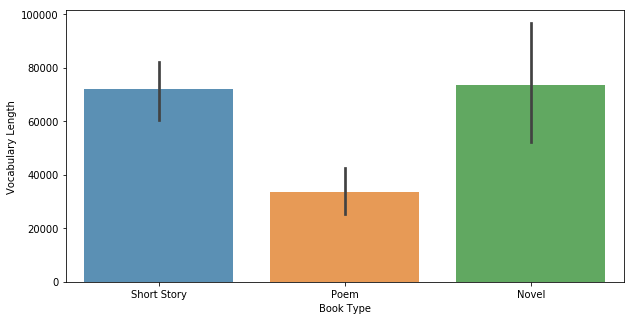

In [16]:
#We can also just plot book length and book type
fig = plt.figure(figsize =(10,5))
sns.barplot(df1["Book Type"], df1["Vocabulary Length"], alpha = 0.8)

#### Which book in our corpus has the most diverse vocabulary and which book has the least diverse?

In [17]:
#This is a tricky one. My first thought was to compare unique vocabulary size. However, this is a wrong method to determine
#vocabulary diversity. As book lengths vary, so do the number of unique vocabulary items found in them. To calculate vocabulary
#diversity, we must normalize it by finding the percentage of unique vocabulary to vocabulary. The "vocabulary diversity score"
#in our dataframe is calculated using this.
df1[df1["Vocabulary Diversity Score"] == df1["Vocabulary Diversity Score"].max()][["Book Name", "Book Type", "Vocabulary Diversity Score"]]

,Book Name,Book Type,Vocabulary Diversity Score
9,Play the Piano Drunk_P,Poem,19.703343


In [18]:
df1[df1["Vocabulary Diversity Score"] == df1["Vocabulary Diversity Score"].min()][["Book Name", "Book Type", "Vocabulary Diversity Score"]]

,Book Name,Book Type,Vocabulary Diversity Score
20,Women_N,Novel,6.205048


#### Is there a correlation between vocabulary diversity and book type?

In [19]:
#Again, as this correlation includes categorical data and numeric data, the best i can do right now is to try to gain
#an intuitive answer
df1[["Book Name","Book Type","Vocabulary Diversity Score"]].sort_values("Vocabulary Diversity Score")
#It appears that there is a correlation, with novels being less diverse in general and poems being more diverse.
#IMPORTANT!
# This may have something to do with the fact that as novels are generally continious narratives, they need to use structure
#words such as "the" "and" "because" more. And as they are also bound by unity of topic, named entities may also be bringing
#their vocabulary score down.
#IMPORTANT

,Book Name,Book Type,Vocabulary Diversity Score
20,Women_N,Novel,6.205048
12,Run With the Hunted_N,Novel,6.414754
4,Ham on Rye_N,Novel,6.701314
16,The Most Beautiful Woman in Town_S,Short Story,7.583469
5,Hollywood_N,Novel,7.876941
14,Tales of Ordinary Madness_S,Short Story,8.017147
6,Hot Water Music_S,Short Story,8.315827
13,South of No North_S,Short Story,8.504024
0,Absence of the Hero_S,Short Story,8.652852
11,Pulp_N,Novel,8.794105


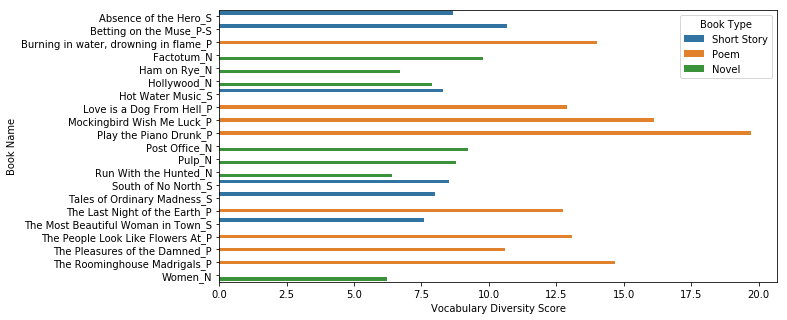

In [20]:
#We can use the same plotting techniques to show this relationship in visual form!
fig = plt.figure(figsize=(10,5))
sns.barplot(x = df1["Vocabulary Diversity Score"], y = df1["Book Name"], hue = df1["Book Type"])
#Here, it's obvious that poems have a higher diversity score than novels AND short stories.

C:\Users\ejgen\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


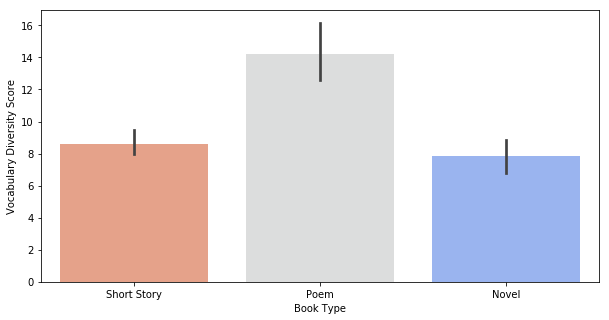

In [21]:
#The same plot using just two variables
fig = plt.figure(figsize=(10,5))
sns.barplot(y = df1["Vocabulary Diversity Score"], x = df1["Book Type"], palette = "coolwarm_r")

#### Is there a correlation between book length and vocabulary diversity?

In [22]:
#As this is a calculation in between numeric data points, we can calculate Pearson Correlation Coefficient easily.
df1[["Vocabulary Length","Vocabulary Diversity Score"]].corr() #There appears to be heavy negative correlation between vocab length
#and vocab diversity score.

,Vocabulary Length,Vocabulary Diversity Score
Vocabulary Length,1.000000,-0.838966
Vocabulary Diversity Score,-0.838966,1.000000


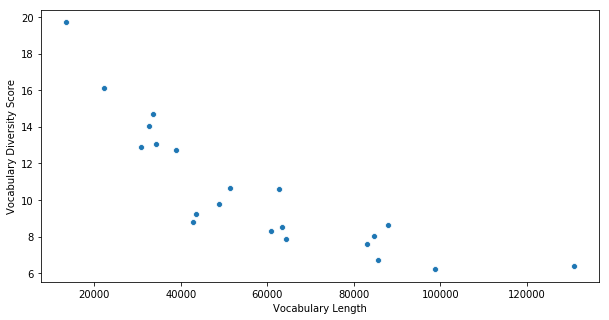

In [23]:
#We can scatterplot this to show correlation!
fig = plt.figure(figsize=(10,5))
sns.scatterplot(df1["Vocabulary Length"], df1["Vocabulary Diversity Score"])
#As vocabulary length increases, the diversity score decreases.

#### Which book in our corpus is the most profane and which is the least profane?

In [24]:
df1[df1["Profanity Rating"] == df1["Profanity Rating"].max()][["Book Name","Book Type","Profanity Rating"]]

,Book Name,Book Type,Profanity Rating
16,The Most Beautiful Woman in Town_S,Short Story,1.306623


In [25]:
df1[df1["Profanity Rating"] == df1["Profanity Rating"].min()][["Book Name","Book Type","Profanity Rating"]]

,Book Name,Book Type,Profanity Rating
2,"Burning in water, drowning in flame_P",Poem,0.510703


#### Is there a correlation between book type and being profane?

In [26]:
#Again, i do not know how to calculate this. But let's try to get an intuition.

In [27]:
df1[["Book Name","Book Type","Profanity Rating"]].sort_values("Profanity Rating") # The appears to be a kind of correlation, but i am not
#sure. But it is obvious that four of his top five most profane books are short stories.

,Book Name,Book Type,Profanity Rating
2,"Burning in water, drowning in flame_P",Poem,0.510703
5,Hollywood_N,Novel,0.547204
18,The Pleasures of the Damned_P,Poem,0.585112
15,The Last Night of the Earth_P,Poem,0.614080
19,The Roominghouse Madrigals_P,Poem,0.619619
9,Play the Piano Drunk_P,Poem,0.627260
8,Mockingbird Wish Me Luck_P,Poem,0.652184
3,Factotum_N,Novel,0.659863
1,Betting on the Muse_P-S,Short Story,0.668577
12,Run With the Hunted_N,Novel,0.677168


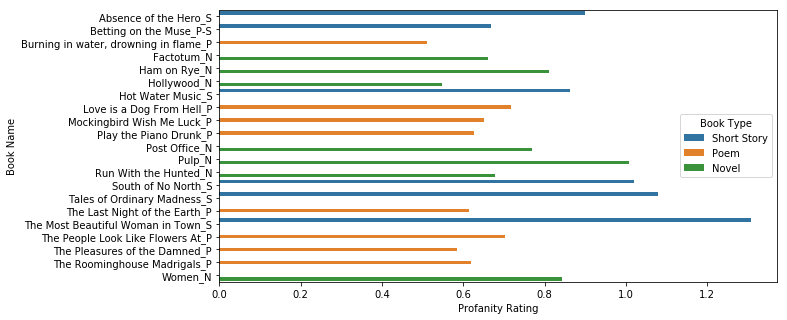

In [28]:
#Let's plot this baby
fig = plt.figure(figsize=(10,5))
sns.barplot(y = df1["Book Name"], x = df1["Profanity Rating"], hue = df1["Book Type"])

#### Which book in our corpus has the biggest amount of profanity in it's unique vocabulary? And the least?

In [29]:
df1[df1["Unique Profanity Rating"] == df1["Unique Profanity Rating"].max()][["Book Name", "Book Type", "Unique Profanity Rating"]]

,Book Name,Book Type,Unique Profanity Rating
16,The Most Beautiful Woman in Town_S,Short Story,1.761066


In [30]:
df1[df1["Unique Profanity Rating"] == df1["Unique Profanity Rating"].min()][["Book Name", "Book Type", "Unique Profanity Rating"]]

,Book Name,Book Type,Unique Profanity Rating
15,The Last Night of the Earth_P,Poem,1.028226


#### Is there a correlation between book type and unique profanity rating?

In [31]:
df1[["Book Name","Book Type","Unique Profanity Rating"]].sort_values("Unique Profanity Rating")

,Book Name,Book Type,Unique Profanity Rating
15,The Last Night of the Earth_P,Poem,1.028226
18,The Pleasures of the Damned_P,Poem,1.053741
19,The Roominghouse Madrigals_P,Poem,1.055838
5,Hollywood_N,Novel,1.124926
2,"Burning in water, drowning in flame_P",Poem,1.134133
7,Love is a Dog From Hell_P,Poem,1.180905
1,Betting on the Muse_P-S,Short Story,1.187865
12,Run With the Hunted_N,Novel,1.191469
9,Play the Piano Drunk_P,Poem,1.235955
20,Women_N,Novel,1.255298


#### Book Dataframe Findings


- Our dataframe is nearly evenly distributed in terms of literary genre. Novels have the most representation with 8 entries and the poems have the lowest representation with 6 entries.

- The longest book in our corpora is the novel "Run With the Hunted." The shortest book in our corpora is the poetry book "Play the Piano Drunk".

- It appears that Bukowski's poems are shorter than his novels, as expected.

- "Play the Piano Drunk", which is the shortest book in the corpora, has the most diverse vocabulary in our corpora while the novel "Women" has the least diverse vocabulary.

- Bukowski's poems are more diverse in vocabulary when compared to his novels and short stories. Also, there appears to be a negative correlation in between book length and vocabulary diversity. The longer a book is, the less diverse it gets.

- The most profane book in our corpus is the short story collection "The Most Beautiful Woman in Town", while the least profane book in our corpus is the poetry book "Burning in Water, Drowning in Flame."

- Bukowski's books which are prose contain more profanity in general than his poems.

- The book that has the highest percentage of profanity in it's unique vocabulary is, once again, the short story "The Most Beautiful Woman in Town." The book with the lowest percentage of profanity in it's unique vocabulary is the poetry book "The Last Night on Earth".

- Bukowski's books which are prose appear to have a higher percentage of profanity in their unique vocabulary when compared with his poems.

#### Swear Word Dataframe

In [32]:
df2.columns = df2.columns.str.replace('Unnamed: 0','Swear Word')

In [103]:
df2.head()

,Swear Word,Absence of the Hero_S,Betting on the Muse_P-S,"Burning in water, drowning in flame_P",Factotum_N,Ham on Rye_N,Hollywood_N,Hot Water Music_S,Love is a Dog From Hell_P,Mockingbird Wish Me Luck_P,...,Run With the Hunted_N,South of No North_S,Tales of Ordinary Madness_S,The Last Night of the Earth_P,The Most Beautiful Woman in Town_S,The People Look Like Flowers At_P,The Pleasures of the Damned_P,The Roominghouse Madrigals_P,Women_N,sum
0,ball,11.0,1.0,3.0,5.0,70.0,6.0,2.0,3.0,2.0,...,27.0,1.0,6.0,8.0,6.0,2.0,4.0,0.0,3.0,162.0
1,sex,43.0,3.0,6.0,1.0,1.0,1.0,5.0,6.0,2.0,...,17.0,10.0,16.0,1.0,9.0,1.0,11.0,5.0,42.0,194.0
2,humping,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,5.0
3,fuck,61.0,10.0,4.0,32.0,37.0,13.0,38.0,17.0,8.0,...,66.0,38.0,54.0,8.0,97.0,10.0,12.0,10.0,86.0,638.0
4,bastard,10.0,6.0,6.0,9.0,7.0,5.0,5.0,1.0,3.0,...,14.0,12.0,17.0,3.0,18.0,5.0,2.0,8.0,10.0,149.0


In [101]:
df2.shape # 202 rows, 23 columns.

(202, 23)

In [119]:
df2.describe() # As this dataframe is a little fucked up, we don't get that much of an meaningful info.

,Absence of the Hero_S,Betting on the Muse_P-S,"Burning in water, drowning in flame_P",Factotum_N,Ham on Rye_N,Hollywood_N,Hot Water Music_S,Love is a Dog From Hell_P,Mockingbird Wish Me Luck_P,Play the Piano Drunk_P,...,Run With the Hunted_N,South of No North_S,Tales of Ordinary Madness_S,The Last Night of the Earth_P,The Most Beautiful Woman in Town_S,The People Look Like Flowers At_P,The Pleasures of the Damned_P,The Roominghouse Madrigals_P,Women_N,sum
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,...,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,3.915842,1.698020,0.826733,1.594059,3.440594,1.742574,2.599010,1.094059,0.717822,0.420792,...,4.386139,3.202970,4.519802,1.183168,5.376238,1.193069,1.816832,1.029703,4.128713,48.678218
std,10.721617,5.545192,2.348849,5.103268,10.814075,5.747859,7.625735,3.500684,2.008583,1.314354,...,12.207143,9.371991,14.676685,4.763158,14.976168,3.520707,5.296306,3.271938,12.857554,132.831395
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,9.000000
75%,3.000000,1.000000,1.000000,1.000000,1.750000,1.000000,2.000000,0.000000,0.750000,0.000000,...,2.000000,2.000000,3.000000,0.750000,3.000000,1.000000,1.000000,1.000000,1.000000,28.000000
max,79.000000,60.000000,19.000000,36.000000,98.000000,52.000000,59.000000,27.000000,17.000000,9.000000,...,85.000000,79.000000,158.000000,58.000000,120.000000,35.000000,59.000000,30.000000,86.000000,1017.000000
